# Separation Of Variable, Fourier Approach

_Refreshed: 2025-10-22_

---

## Table of Contents
- [Example $V_0$:](#example-v-0)
  - [Plot for $n=1$, $a=1$, $V_0=1$](#plot-for-n-1-a-1-v-0-1)
  - [Meshgrid plot](#meshgrid-plot)
  - [V(x,y) contour plot](#v-x-y-contour-plot)
  - [V(x,y) surface plot](#v-x-y-surface-plot)
  - [V(x,y) animation for various n](#v-x-y-animation-for-various-n)

In [1]:
# Common utilities for this notebook (2025 refresh)
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=6, suppress=True)
plt.rcParams.update({"figure.dpi": 140, "figure.autolayout": True})

def savefig(name: str, dpi: int = 220):
    """
    Save a figure as PNG and SVG to the local 'figures' folder.
    """
    import os
    os.makedirs("figures", exist_ok=True)
    if not name.lower().endswith(".png"):
        png = f"{name}.png"
        svg = f"{name}.svg"
    else:
        png = name
        svg = name.replace(".png", ".svg")
    plt.savefig(os.path.join("figures", png), dpi=dpi, bbox_inches="tight")
    plt.savefig(os.path.join("figures", svg), bbox_inches="tight")
    print(f"Saved figures/{png} and figures/{svg}")

# Separation of Variable, the fourier approach
following Griffiths Introduction of electrodynamics, third edition 

Two infinite grounded metal plates lie parallel to the $xz$ plane, one at $y=0$, the other at $y=a$. The left end, at $x=0$, is closed off with an infinite strip insulated from the two plates and mantained at a specific potential $V_0(y)$. Find the potential inside this "slot".

Since the solution is independent of $z$ is is actually a 2D problem and thus:

$$\frac{\partial^2V}{\partial x^2}+\frac{\partial^2V}{\partial y^2}=0 \label{eq:1}\tag{1}$$

with the boundary conditions:

1. $V=0$ when $y=0$
2. $V=0$ when $y=a$
3. $V=V_0(y)$ when $x=0$
4. $V\rightarrow0$ as $x\rightarrow \infty$

We want to find the solutions in the form of products:

$$V(x,y)=X(x)Y(y)\tag{2}$$

Putting eq.2 into eq.1:

$$Y\frac{d^2X}{dx^2}+X\frac{d^2Y}{dy^2}$$

_Separation of variables_ by divinding by $V$:

$$\frac 1 X \frac{d^2X}{dx^2}+\frac 1 Y \frac{d^2Y}{dy^2}=0\tag{3}$$

which gives as an equation in the form:

$$f(x)+g(y)=0$$

which is only possible if f and g are both _constant_.

With that it follows for eq.3:

$$\frac 1 X \frac{d^2X}{dx^2}=C_1$$ and $$\frac 1 Y \frac{d^2Y}{dy^2}=C_2$$ with $$C_1+C_2=0$$

So either $C_1$ or $C_2$ has to be negative (or both are zero). We want $C_1$ to be positive (and thus $C_2$ negative).

So we converted a PDE into two ODEs:

$$ \frac{d^2X}{dx^2} = k^2X $$ with $k^2$ always positive, and
$$ \frac{d^2Y}{dy^2} = -k^2Y $$ with $-k^2$ always negative

Either we know the solutions for these ODEs (or look them up) or we let the computer solve them analyticly:

In [2]:
from sympy.interactive import printing # use latex for printing
printing.init_printing(use_latex=True)
from sympy import Function, dsolve, Eq, Derivative, sin, cos, symbols, simplify, real_roots # import necessary methods
from sympy.abc import x,y # import variables

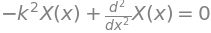

In [4]:
X = Function('X',real=True)
k = symbols('k',positive=True)
f1_ode = Eq(Derivative(X(x), x, 2) - k**2*X(x),0)
f1_ode

In [5]:
dsolve(f1_ode, X(x))

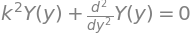

In [6]:
Y = Function('Y',real=True)
f2_ode = Eq(Derivative(Y(y), y, 2) + k**2*Y(y),0)
f2_ode

In [7]:
dsolve(f2_ode, Y(y))

Which gives us:
$$V(x,y)=\left (A\textrm{e}^{kx}+B\textrm{e}^{-kx}\right)\left(C\sin{ky}+D\cos{ky}\right)$$

Determine constants out of the boundary conditions:

4. $V\rightarrow0$ as $x\rightarrow \infty$

$\rightarrow A=0$

$$V(x,y)=\textrm{e}^{-kx}\left(C/B\sin{ky}+D/B\cos{ky}\right)$$
1. $V=0$ when $y=0$

$\rightarrow D/B=0$
$$V(x,y)=C/B\textrm{e}^{-kx}\sin{ky}$$

2. $V=0$ when $y=a$

$\rightarrow \sin ka=0$
$$k=\frac{n\pi}{a},\ \ (n=1,2,3,\ldots)$$

Out of:
3. $V=V_0(y)$ when $x=0$

this gives us the solution for one specific $V_0(y)\propto\sin(n\pi y/a)$

Since Laplace's equation is linear and thus:
$$\Delta V=\alpha_1\Delta V_1+\alpha_2\Delta V_2+\ldots=0\alpha_1+0\alpha_2+\ldots=0$$

We can use the the sum (which is the Fourier series) which gives us all possible solutions for an arbitrary $V_0(y)$
$$ V(x,y)=\sum^{\infty}_{n=1}C_n\textrm{e}^{-n\pi x/a}\sin(n\pi y/a)$$ and satisfies the boundary conditions.

Now we use boundary condition (3) to find the coefficients $C_n$, by multplying $V(0,y)$ by $\sin(n'\pi y/a)$ with $n'$ a positige integer and integratin from 0 to $a$: 

$$ \sum^{\infty}_{n=1}C_n\int_0^a \sin(n\pi y/a)  \sin(n'\pi y/a)\,dy = \int_0^a V_0(y) \sin(n'\pi y/a)\,dy $$

In [8]:
from sympy import integrate, pi
n, m = symbols('n m', positive = True, integer=True)
a = symbols('a', constant = True)
integrate (sin(n*pi*y/a)*sin(m*pi*y/a), (y, 0, a)) # var y, from 0 to a

⎧0  for m ≠ n
⎪            
⎨a           
⎪─  otherwise
⎩2           

and thus all terms drop out, but $n=n'$ so we get for the coefficients $C_n$:

$$ C_n = \frac 2 a \int_0^a V_0 \sin(n\pi y/a)\,dy$$

## Example $V_0$:

For the strip at $x=0$ at a constant potential $V_0$:

$$C_n=\frac{2V_0}{a}\int_0^a\sin(n\pi y/a)dy=\frac{2V_0}{n\pi}(1-\cos n\pi)=
\begin{cases}
    0, & \text{if $n$ is even}.\\
    \frac{4V_0}{n\pi}, & \text{if $n$ is odd}.
\end{cases}$$

Putting it all together:
$$ V(x,y)=\frac{4V_0}{\pi}\sum_{n=1,3,5,\ldots}\frac 1 n \textrm{e}^{-n\pi x/a}\sin(n\pi y/a)$$

### Plot for $n=1$, $a=1$, $V_0=1$

In [9]:
import numpy as np
import matplotlib.pyplot as plt

In [10]:
a = 1
x = np.arange(0,1.01,0.05)  # range for x
y = np.arange(0,a+0.01,0.05)  # range for y
X,Y = np.meshgrid(x,y)  # generate 2D mesh from x and y

### Meshgrid plot

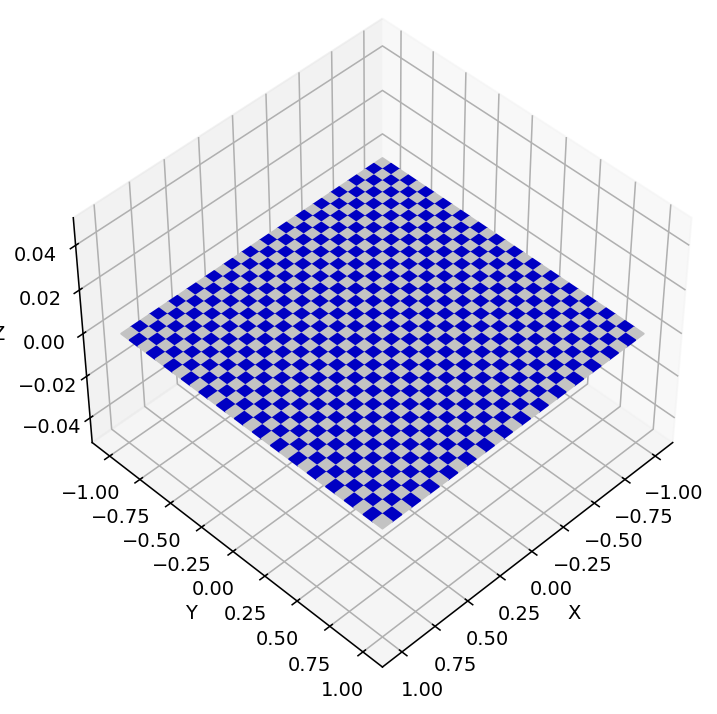

In [16]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # registers 3D projection

# Example grid
x = np.linspace(-1, 1, 30)
X, Y = np.meshgrid(x, x)

fig = plt.figure(figsize=(5, 5))            # ✅ create figure inside this cell
ax = fig.add_subplot(111, projection='3d')  # ✅ attach 3D axes

# Generate checker pattern
colortuple = ('w', 'b')
colors = np.empty(X.shape, dtype=str)
for i in range(len(x)):
    for j in range(len(x)):
        colors[i, j] = colortuple[(i + j) % len(colortuple)]

# Plot the surface
surf = ax.plot_surface(X, Y, np.zeros_like(X), rstride=1, cstride=1, facecolors=colors)

# Optional view angle / labels
ax.view_init(elev=45, azim=45)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.show()


### V(x,y) contour plot

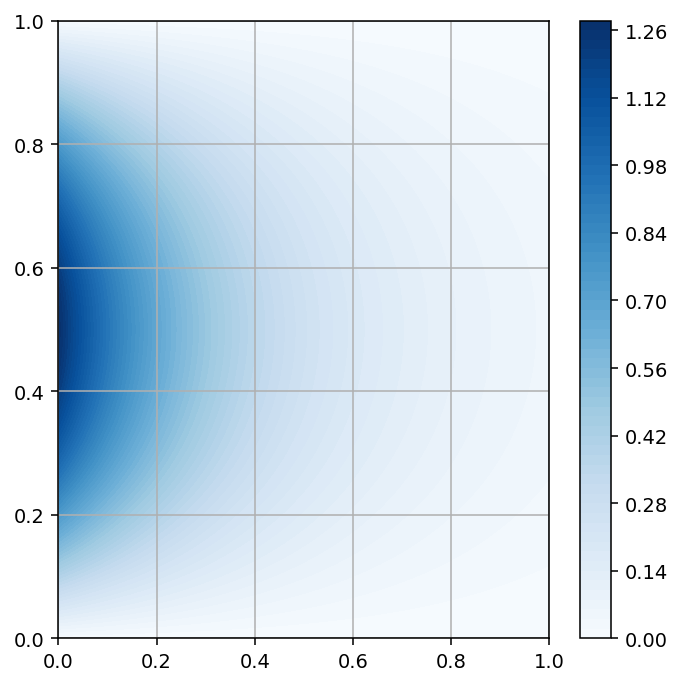

In [17]:
n=1
a=1
V0 = 1
x = np.arange(0,1.01,0.01)  # range for x
y = np.arange(0,a+0.01,0.01)  # range for y
X,Y = np.meshgrid(x,y)  # generate 2D mesh from x and y
V=(4*V0/np.pi)*(1/n*np.exp(-n*np.pi*X/a)*np.sin(n*np.pi*Y/a))  # define V(x,y) on the mesh X,Y

fig = plt.figure(figsize=(5.,5.))
ax = fig.gca()
cf = ax.contourf(X,Y,V,64,cmap='Blues')
ax.grid()
plt.colorbar(cf)

### V(x,y) surface plot

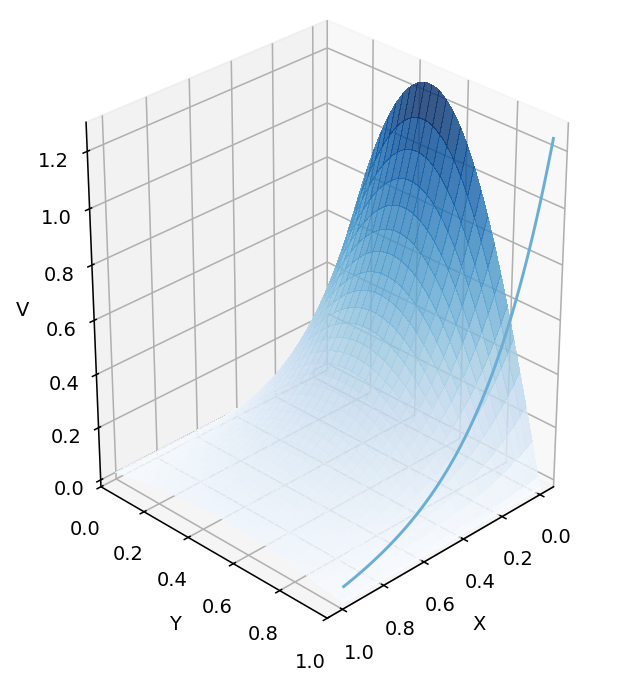

In [19]:
# %matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # registers the 3D projection

fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111, projection='3d')  # ✅ replace gca(...)

# Surface
surf = ax.plot_surface(
    X, Y, V,
    cmap='Blues',
    alpha=0.8,
    linewidth=0,
    antialiased=False
)

# Put the contour on the plane y = max(Y) so it actually shows
y_offset = float(np.max(Y))  # pick a visible offset inside y-limits
cset = ax.contour(
    X, Y, V,
    zdir='y',
    offset=y_offset,
    cmap='Blues',
    levels=1
)

# Ensure the offset plane is within the displayed limits
ax.set_ylim(np.min(Y), y_offset)

# Optional: nicer view/aspect and labels
ax.view_init(elev=30, azim=45)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('V')
try:
    ax.set_box_aspect([np.ptp(X), np.ptp(Y), np.ptp(V)])  # Matplotlib >=3.3
except Exception:
    pass

# Annotation — keep it inside current


### V(x,y) animation for various n

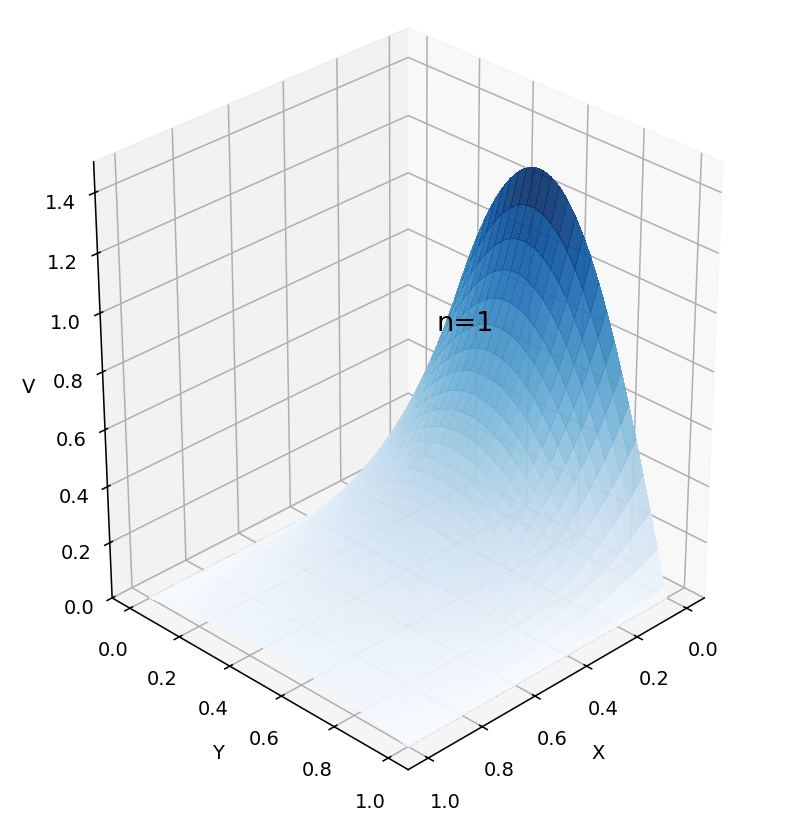

In [21]:
# %matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML
from matplotlib.animation import FuncAnimation

# --- Assumes X, Y, a, V0 already exist. If not, uncomment this example grid: ---
# a, V0 = 1.0, 1.0
# x = np.linspace(0, a, 60)
# y = np.linspace(0, a, 60)
# X, Y = np.meshgrid(x, y, indexing='xy')

# Potential term
def V_n(X, Y, n, a, V0):
    return (4*V0/np.pi) * (1/n * np.exp(-n*np.pi*X/a) * np.sin(n*np.pi*Y/a))

# Build cumulative partial sums over n
n_range = np.arange(1, 28, 2)  # 1,3,5,...,27
zarray = np.zeros((X.shape[0], Y.shape[1], len(n_range)))
for i, n in enumerate(n_range):
    term = V_n(X, Y, n, a, V0)
    zarray[:, :, i] = term if i == 0 else zarray[:, :, i-1] + term

# Figure & 3D axis
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')

# Initial artists
surf = ax.plot_surface(X, Y, zarray[:, :, 0], cmap="Blues", linewidth=0, antialiased=False, alpha=0.9)
txt  = ax.text(
    0.7*(X.max()-X.min())+X.min(),
    0.8*(Y.max()-Y.min())+Y.min(),
    zarray[:, :, -1].max(),  # put text near top
    f"n={n_range[0]}",
    color='k', fontsize=14
)

# Axis cosmetics
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('V')
ax.view_init(elev=30, azim=45)
ax.set_zlim(0, max(1.5, zarray[:, :, -1].max()))
try:
    ax.set_box_aspect([np.ptp(X), np.ptp(Y), np.ptp(zarray[:, :, -1])])
except Exception:
    pass

# Update function (rebuild surface each frame; 3D doesn't support blitting)
def update_plot(frame_number):
    global surf, txt
    # remove old artists
    surf.remove()
    txt.remove()
    # add new ones
    surf = ax.plot_surface(
        X, Y, zarray[:, :, frame_number],
        cmap="Blues", linewidth=0, antialiased=False, alpha=0.9
    )
    txt = ax.text(
        0.7*(X.max()-X.min())+X.min(),
        0.8*(Y.max()-Y.min())+Y.min(),
        zarray[:, :, -1].max(),
        f"n={n_range[frame_number]}",
        color='k', fontsize=14
    )
    return surf, txt

anim = FuncAnimation(fig, update_plot, frames=len(n_range), interval=400, blit=False)

# Show inline without ffmpeg
plt.rcParams['animation.html'] = 'jshtml'
HTML(anim.to_jshtml())


In [22]:
from matplotlib.animation import FuncAnimation, PillowWriter

# (Assumes you already have X, Y, zarray, n_range, etc.)

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X, Y, zarray[:, :, 0], cmap="Blues", linewidth=0, antialiased=False, alpha=0.9)
txt = ax.text(0.7*(X.max()-X.min())+X.min(),
              0.8*(Y.max()-Y.min())+Y.min(),
              zarray[:, :, -1].max(),
              f"n={n_range[0]}", color='k', fontsize=14)

ax.set_zlim(0, max(1.5, zarray[:, :, -1].max()))
ax.view_init(elev=30, azim=45)

def update_plot(frame):
    global surf, txt
    surf.remove()
    txt.remove()
    surf = ax.plot_surface(X, Y, zarray[:, :, frame],
                           cmap="Blues", linewidth=0, antialiased=False, alpha=0.9)
    txt = ax.text(0.7*(X.max()-X.min())+X.min(),
                  0.8*(Y.max()-Y.min())+Y.min(),
                  zarray[:, :, -1].max(),
                  f"n={n_range[frame]}", color='k', fontsize=14)
    return surf, txt

anim = FuncAnimation(fig, update_plot, frames=len(n_range), interval=400, blit=False)

# --- Save animation as GIF (GitHub-friendly) ---
anim.save("animation.gif", writer=PillowWriter(fps=20))
plt.close(fig)
print("✅ Saved animation.gif")


✅ Saved animation.gif


![3D animation](animation.gif)